Nome: Lucas Fiuza Garcia

RA:300901

Curso:Engenharia Elétrica



# Ex02 - Histograma e Extração de Características

Esta atividade tem 2 objetivos principais:
  - Entender o conceito de histograma e estatísticas da imagem;
  - Explorar diferentes formas de extração de características em histogramas e sua aplicação em um problema de classificação.

In [323]:
# Importando as bibliotecas que serão utilizadas
from io import BytesIO
import os
import random

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image, ImageFile
import requests
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier

## Parte 1 - Histograma

Leia o notebook [Histograma de imagens](https://github.com/lrittner/Computacao-Visual/blob/master/tutoriais/05_Histograma_da_imagem.ipynb) para entender o conceito de histograma e o uso da função *np.histogram*. Tente também entender a função a seguir, que plota o histograma usando gráfico de barras. Essa função será muito útil nos exercícios deste notebook.

In [324]:
def plota_hist(h,cor,nbins,bin_edges):

    w=255./nbins
    bin_centers = bin_edges[1:]-(w/2)
    plt.bar(bin_centers, h, width=w, color=cor)

### Exercício 1.1

Vamos tentar calcular o histograma de imagens coloridas. Para isso, utilize as imagens tiradas durante o dia ou durante a noite, lidas e apresentadas pelo código abaixo. Observe que elas estão na lista `all_imgs`, sendo a primeira metade as imagens de dia, e a segunda as imagens de noite.

Plote os histogramas de cada uma das bandas das imagens usando gráficos de barras (função `plota_hist`). Compare visualmente os histogramas e comente as principais diferenças observadas. Se você tivesse que dizer quais histogramas pertencem a quais classes de imagem (dia ou noite), você seria capaz de acertar? Explique porque.

In [325]:
def read_image_url(url:str) -> np.ndarray:
    response = requests.get(url)
    img = Image.open(BytesIO(response.content))
    img = np.array(img)

    return img

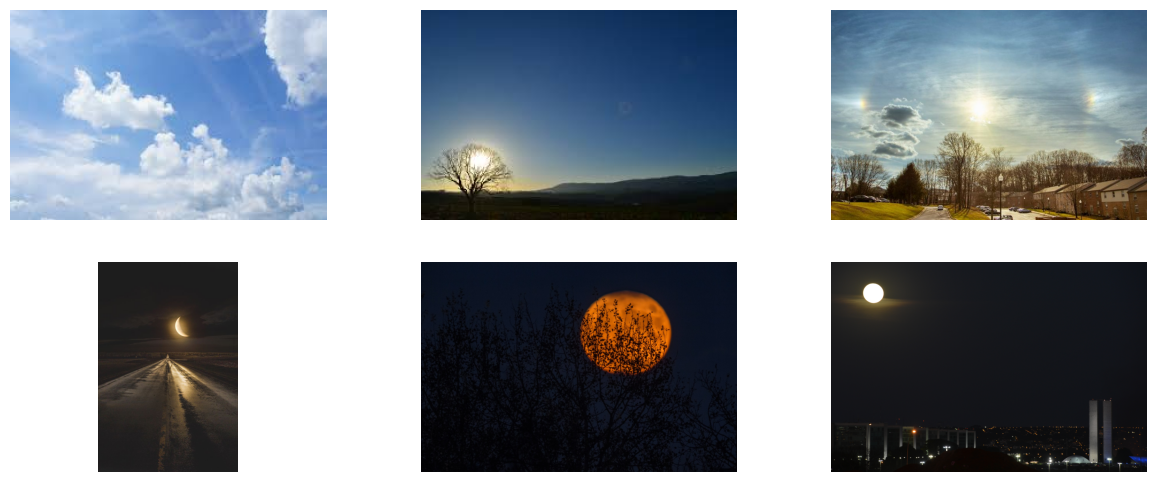

In [326]:
base_path = r"https://raw.githubusercontent.com/UNICAMP-EA979/EA979-Recursos/refs/heads/main/imgs/{img_name}.jpg"

fig, axs = plt.subplots(2,3,figsize=(15, 6))

all_imgs = []

index = 0
for daytime in ["dia", "noite"]:

  for i in range(3):
    img_name = daytime+"_"+str(i+1)
    img = read_image_url(base_path.format(img_name=img_name))
    all_imgs.append(img)

    plt.subplot(2,3,1+index)
    plt.axis('off')
    plt.imshow(img)

    index += 1

Os histogramas das imagens de dia tem as frequências mais distribuídas, e apresentam uma frequência bem maior de intencidades altas (mais claro) do que os histogramas 
 noturnos. As imagens noturnas são bem mais escuras e tem menos variação de intensidade, então seus histogramas são bem concentrados em intensidades mais baixas
 Outra diferença perceptível é quão separadas estão as 3 bandas das imagens de dia, e quão sobrepostas ficam as das imagens de noite, dado quão pouca variação de cor existe
  nas imagens noturnas.

 Acredito que eu seria capaz de acertar ao tentar identificar as imagens, considerando as diferenças tão perceptíveis nos histogramas.
 Caso o histograma apresentasse um grande concentração das 3 bandas em intensidades baixas eu diria que sua imagem é noturna, enquanto diria que é diurna caso as bandas
  sejam mais separadas e/ou se distribuam de forma a apresentar uma frequência maior de intensidades altas.


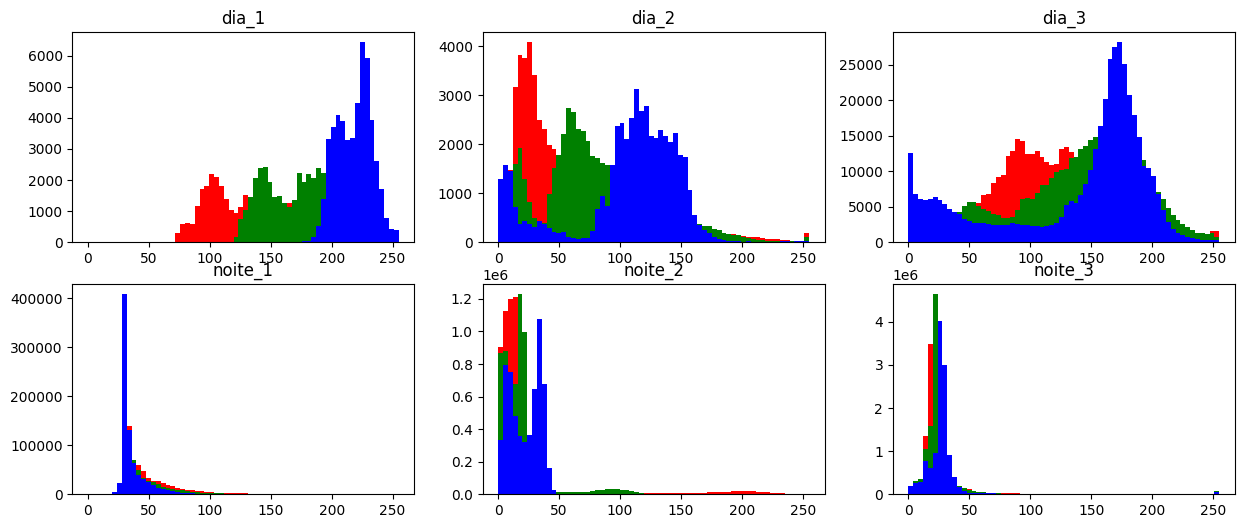

In [327]:
# Seu código aqui
fig, axs = plt.subplots(2,3,figsize=(15, 6))

nbins = 64

index = 0
for daytime in ["dia", "noite"]:
  for i in range(3):
    img = all_imgs[index]
    plt.subplot(2,3,1+index)

    #bandas
    r = img[:,:,0]
    g = img[:,:,1]
    b = img[:,:,2]

    # histogramas
    hr, bin_edges = np.histogram(r, bins=nbins, range=(0,255))
    hg, _ = np.histogram(g, bins=nbins, range=(0,255))
    hb, _ = np.histogram(b, bins=nbins, range=(0,255))

    # plotar
    plota_hist(hr, 'red', nbins, bin_edges)
    plota_hist(hg, 'green', nbins, bin_edges)
    plota_hist(hb, 'blue', nbins, bin_edges)

    img_name = daytime+"_"+str(i+1)
    plt.title(img_name)

    index += 1


print("Os histogramas das imagens de dia tem as frequências mais distribuídas, e apresentam uma frequência bem maior de intencidades altas (mais claro) do que os histogramas \n",
      "noturnos. As imagens noturnas são bem mais escuras e tem menos variação de intensidade, então seus histogramas são bem concentrados em intensidades mais baixas\n",
      "Outra diferença perceptível é quão separadas estão as 3 bandas das imagens de dia, e quão sobrepostas ficam as das imagens de noite, dado quão pouca variação de cor existe\n",
      " nas imagens noturnas.\n\n",
      "Acredito que eu seria capaz de acertar ao tentar identificar as imagens, considerando as diferenças tão perceptíveis nos histogramas.\n",
      "Caso o histograma apresentasse um grande concentração das 3 bandas em intensidades baixas eu diria que sua imagem é noturna, enquanto diria que é diurna caso as bandas\n",
      " sejam mais separadas e/ou se distribuam de forma a apresentar uma frequência maior de intensidades altas."
      )

### Exercício 1.2

Selecione duas imagens coloridas do item anterior (uma de dia e uma de noite) e faça a conversão para níveis de cinza, usando os métodos abaixo:
   - médias das bandas R, G, B;
   - média ponderada das bandas R, G, B: procure qual a poderação mais utilizada;
   - convert(L) da biblioteca PIL (utilize `Image.fromarray(array)` para converter o array para uma imagem do PIL);

Em seguida, calcule o histograma das imagens convertidas para níveis de cinza. Compare os histogramas em níveis de cinza e discuta novamente as diferenças.   

Assim como no exercício anterior, a distinção entre dia e noite é bem clara. os histogramas de noite são bem focados em frequencias baixas 
 (e bem similares aos coloridos devido à sobreposição dos histogramas das 3 bandas), enquanto os de dia são mais distribuídos.
 
As três maneiras de converter a imagem para escala de cinza geraram histogramas bem similares. Quando comparada à média simples, a conversão
 usando média ponderada  deslocou e suavizou levemente o histograma devido à maior importância do canal verde no cálculo. A conversão utilizando 
 'convert('L')' se assemelhou muito à média ponderada por utilizar um cálculo similar.


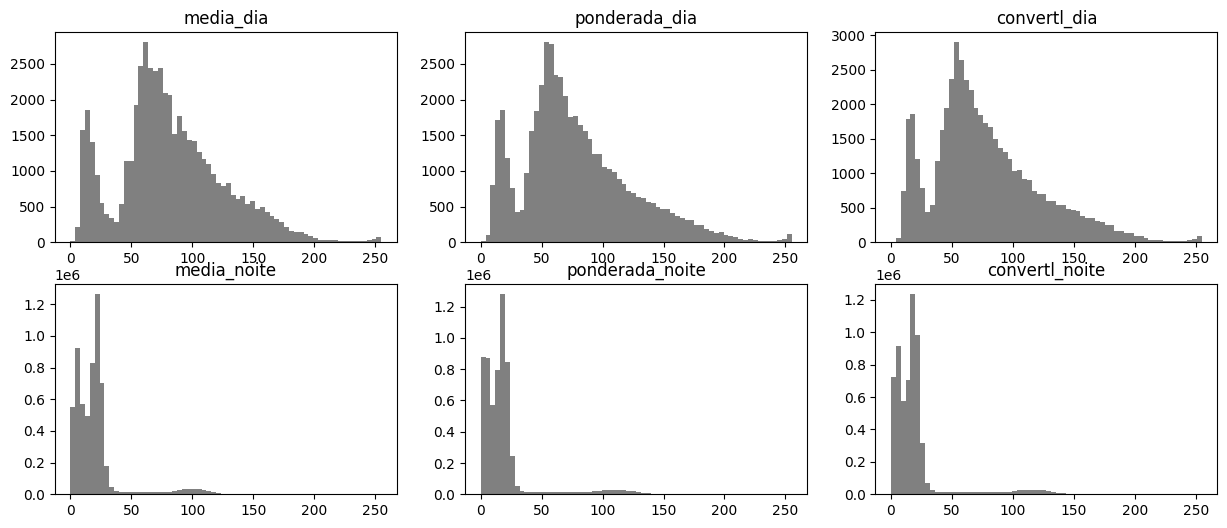

In [328]:
# Seu código aqui
img_dia = all_imgs[1]
img_noite = all_imgs[4]

# Média das bandas R, G, B
media_dia = np.mean(img_dia, axis=2)
media_noite = np.mean(img_noite, axis=2)

# Média ponderada
pond_dia = 0.21*img_dia[:,:,0] + 0.72*img_dia[:,:,1] + 0.07*img_dia[:,:,2]
pond_noite = 0.21*img_noite[:,:,0] + 0.72*img_noite[:,:,1] + 0.07*img_noite[:,:,2]

# Conver(L)
convertl_dia = Image.fromarray(img_dia).convert('L')
convertl_noite = Image.fromarray(img_noite).convert('L')

# Histogramas
nbins = 64

hmedia_dia, bin_edges = np.histogram(media_dia, bins=nbins, range=(0,255))
hmedia_noite, _ = np.histogram(media_noite, bins=nbins, range=(0,255))

hpond_dia, _ = np.histogram(pond_dia, bins=nbins, range=(0,255))
hpond_noite, _ = np.histogram(pond_noite, bins=nbins, range=(0,255))

hconvertl_dia, _ = np.histogram(convertl_dia, bins=nbins, range=(0,255))
hconvertl_noite, _ = np.histogram(convertl_noite, bins=nbins, range=(0,255))

# Plotando
fig, axs = plt.subplots(2,3,figsize=(15, 6))

plt.subplot(2,3,1)
plota_hist(hmedia_dia, 'grey', nbins, bin_edges)
plt.title("media_dia")

plt.subplot(2,3,4)
plota_hist(hmedia_noite, 'grey', nbins, bin_edges)
plt.title("media_noite")

plt.subplot(2,3,2)
plota_hist(hpond_dia, 'grey', nbins, bin_edges)
plt.title("ponderada_dia")

plt.subplot(2,3,5)
plota_hist(hpond_noite, 'grey', nbins, bin_edges)
plt.title("ponderada_noite")

plt.subplot(2,3,3)
plota_hist(hconvertl_dia, 'grey', nbins, bin_edges)
plt.title("convertl_dia")

plt.subplot(2,3,6)
plota_hist(hconvertl_noite, 'grey', nbins, bin_edges)
plt.title("convertl_noite")

print("Assim como no exercício anterior, a distinção entre dia e noite é bem clara. os histogramas de noite são bem focados em frequencias baixas \n",
      "(e bem similares aos coloridos devido à sobreposição dos histogramas das 3 bandas), enquanto os de dia são mais distribuídos.\n",
      "\nAs três maneiras de converter a imagem para escala de cinza geraram histogramas bem similares. Quando comparada à média simples, a conversão\n",
      "usando média ponderada  deslocou e suavizou levemente o histograma devido à maior importância do canal verde no cálculo. A conversão utilizando \n",
      "'convert('L')' se assemelhou muito à média ponderada por utilizar um cálculo similar.")


## Parte 2 - Extraindo atributos derivados do histograma

Histogramas podem ser utilizados para extrair atributos de imagens. Estes dados são úteis em tarefas de aprendizado de máquina, como a classificação de imagens.

Dentre os atribitos mais comuns usados para a classificação de imagens, estão: *média*, *variância*, *assimetria* e *curtose*.

A função abaixo calcula, dada uma imagem em níveis de cinza, o histograma e seus atributos. Além dos atributos listados acima, ela também calcula os percentis 1, 10, 50, 90 e 99%.

In [329]:
def histstat(f):

    h, bin_edges = np.histogram(f, 256, (0,255))
    hn = 1.0*h/h.sum() # compute the normalized image histogram
    cum_hn = np.cumsum(hn) # compute the cumulative image histogram
    v = np.zeros(9) # number of statistics

    # compute statistics
    n = len(h) # number of gray values
    v[0]  = np.sum((np.arange(n)*hn)) # mean
    v[1]  = np.sum(np.power((np.arange(n)-v[0]),2)*hn) # variance
    v[2]  = np.sum(np.power((np.arange(n)-v[0]),3)*hn)/(np.power(v[1],1.5)) # skewness
    v[3]  = np.sum(np.power((np.arange(n)-v[0]),4)*hn)/(np.power(v[1],2))-3 # kurtosis
    v[4] = np.where(cum_hn >= 0.01)[0][0] # 1% percentile
    v[5] = np.where(cum_hn >= 0.1)[0][0] # 10% percentile
    v[6] = np.where(cum_hn >= 0.5)[0][0] # 50% percentile
    v[7] = np.where(cum_hn >= 0.9)[0][0] # 90% percentile
    v[8] = np.where(cum_hn >= 0.99)[0][0] # 99% percentile

    return v

Se quisermos então extrair os atributos de histograma de uma das imagens tiradas durante o dia, basta fazermos:

In [330]:
f = all_imgs[0]
f_gray = np.uint8(0.3*f[:,:,0]+0.59*f[:,:,1]+0.11*f[:,:,2]) # Conversão para níveis de cinza
hist_features = histstat(f_gray)
for feature in hist_features:
  print(f'{feature:.2f}')

175.75
1035.83
-0.03
-1.11
118.00
132.00
178.00
218.00
237.00


### Exercício 2.1

Extraia agora os atributos de uma das imagens tiradas durante a noite e compare com os atributos da imagem anterior. Eles parecem suficientemente diferentes para distinguir uma da outra?

In [331]:
# Seu código aqui
f = all_imgs[3]
f_gray = np.uint8(0.3*f[:,:,0]+0.59*f[:,:,1]+0.11*f[:,:,2]) # Conversão para níveis de cinza
hist_features = histstat(f_gray)
for feature in hist_features:
  print(f'{feature:.2f}')

print("\n\nos atributos da imagem noturna apresentam valores de média, variância e percentis bem mais baixos que a imagem de dia, enquanto assimetria e kurtose\n",
      "são bem mais altos (sendo negativos no dia). Essa diferença mostra que são suficientemente diferentes para distinguir uma da outra:\n",
      "\t-> A média e os percentis mostram que as intensidades da imagem noturna são bem mais baixas que as da imagem diurna\n",
      "\t-> A variância mostra que os valores estão menos distribuídos na imagem noturna\n ",
      "\t-> A assimetria evidencia a grande concentração de valores à esquerda na noturna (muitos pixels escuros)\n",
      "\t-> A Kurtose mostra que a curva tem um pico muito alto na imagem noturna (concentração de valores similares escuros)")

43.47
704.20
3.65
16.82
28.00
29.00
33.00
69.00
179.00


os atributos da imagem noturna apresentam valores de média, variância e percentis bem mais baixos que a imagem de dia, enquanto assimetria e kurtose
 são bem mais altos (sendo negativos no dia). Essa diferença mostra que são suficientemente diferentes para distinguir uma da outra:
 	-> A média e os percentis mostram que as intensidades da imagem noturna são bem mais baixas que as da imagem diurna
 	-> A variância mostra que os valores estão menos distribuídos na imagem noturna
  	-> A assimetria evidencia a grande concentração de valores à esquerda na noturna (muitos pixels escuros)
 	-> A Kurtose mostra que a curva tem um pico muito alto na imagem noturna (concentração de valores similares escuros)


## Parte 3 - Classificação de imagens utilizando atributos derivados do histograma

### O classificador dos K-vizinhos mais próximos (KNN ou K-Nearest Neighbors)

[KNN (K-Nearest Neighbors)](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html) é um algoritmo de classificação que usa uma abordagem baseada em instâncias, ou seja, ele classifica uma nova amostra com base nas amostras mais próximas (vizinhas) a ela. O KNN se baseia na suposição de que amostras próximas no espaço de atributos estão mais propensas a pertencer à mesma classe.

Para classificar imagens usando o algoritmo KNN, primeiro o conjunto de dados de treinamento é utilizado para construir uma representação dos dados que permita a busca dos vizinhos mais próximos.

Em seguida, para classificar uma nova amostra, o algoritmo encontra as K amostras mais próximas na representação construída, em que K é um parâmetro definido pelo usuário.

Por fim, a classe da nova amostra é determinada pela classe mais comum entre os vizinhos encontrados.



### Exemplo de uso do KNN:

Um conjunto de dados de duas classes é gerado aleatoriamente e, em seguida, o modelo KNN é treinado com k=5 vizinhos próximos. Note que a função **KNeighborsClassifier()** foi importada da biblioteca **sklearn.neighbors** e foi utilizada para criar o modelo KNN. A função *fit()* foi utilizada para treinar o modelo

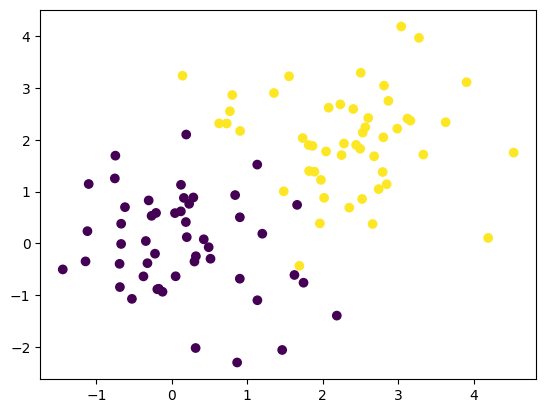

In [332]:
# Geração de dados aleatórios
np.random.seed(1)
X1 = np.random.randn(50, 2)  # 50 amostras da classe 1
X2 = np.random.randn(50, 2) + 2  # 50 amostras da classe 2
X = np.concatenate((X1, X2))
Y = np.concatenate((np.zeros(50), np.ones(50))) # rótulos das classes (0 e 1)

# Visualizando as amostras (coloridas por classe)
plt.scatter(X[:,0],X[:,1],c=Y)
plt.show()

# Criando o modelo KNN
model = KNeighborsClassifier(n_neighbors=5)

# Treinando o modelo
model.fit(X, Y);

Em seguida, novas amostras aleatórias foram criadas para teste e o modelo foi utilizado para classificá-las.

A função *predict()* é utilizada para classificar as novas amostras.



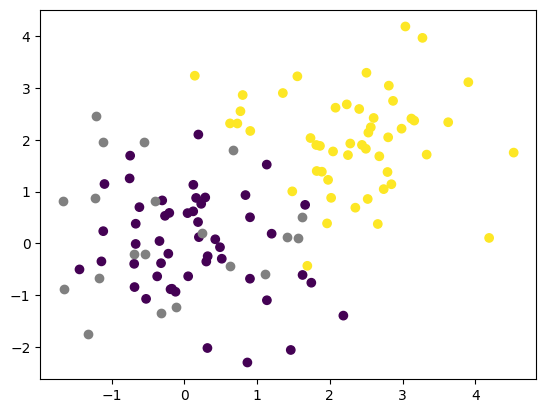

In [333]:
# Criando novas amostras aleatórias para teste
X_test = np.random.randn(20, 2)

#  Visualizando o conjunto de teste
plt.scatter(X[:,0],X[:,1],c=Y)
plt.scatter(X_test[:,0],X_test[:,1],c='gray')
plt.show()

# Classificando as amostras
Y_test_pred = model.predict(X_test)

Para avaliar a qualidade de um classificador, normalmente se utiliza as seguintes métricas:

- [Acurácia (accuracy_score)](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html): mede a proporção de amostras classificadas corretamente pelo modelo.
- [Precisão (precision_score)](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_score.html): mede a proporção de amostras classificadas como positivas (1) que são realmente positivas.
- [Recall (recall_score)](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.recall_score.html): mede a proporção de amostras positivas (1) que são corretamente identificadas pelo modelo.
- [F1-Score (f1_score)](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html): média harmônica entre precisão e recall.

Note que estas não são as únicas métricas utilizadas para avaliar um classificador. A escolha das métricas depende do contexto e dos objetivos da classificação. Na medicina, por exemplo, costuma-se utilizar a sensibilidade (ou recall) e a especificidade (mede a proporção de amostras negativas (0) que são corretamente identificadas pelo modelo). Dessa forma, pode-se determinar em que medida o classificador/exame é sensível à condição em questão (detecta corretamente as amostras positivas) e específico para detectar apenas ela (detecta corretamente as amostras negativas).

**Atenção**: para avaliar o modelo, as métricas foram calculadas em relação às amostras de treinamento, o que **não** é o ideal em um cenário real de classificação. No entanto, para fins didáticos, pode-se utilizar essas métricas para avaliar o desempenho do modelo.

In [334]:
# Avaliando o modelo (as funções foram importadas previamente da biblioteca sklearn.metrics)
acc = accuracy_score(Y, model.predict(X))
prec = precision_score(Y, model.predict(X))
rec = recall_score(Y, model.predict(X))
f1 = f1_score(Y, model.predict(X))

# Imprimindo as métricas
print('Acurácia: %.2f' % acc)
print('Precisão: %.2f' % prec)
print('Recall: %.2f' % rec)
print('F1-Score: %.2f' % f1)

Acurácia: 0.96
Precisão: 0.94
Recall: 0.98
F1-Score: 0.96


Para fazer uma avaliação qualitativa do classificador, podemos plotar os resultados da classificação utilizando a função [scatter()](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html) do matplotlib. As amostras de treinamento são plotadas com pontos circulares, enquanto as amostras de teste são plotadas com pontos cruzados.


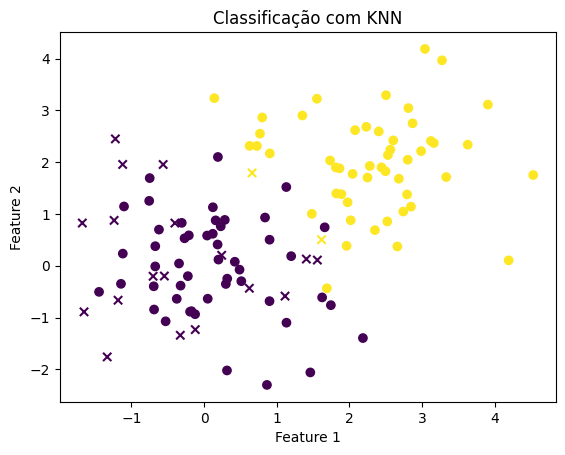

In [335]:
# Plotando os resultados
plt.scatter(X[:, 0], X[:, 1], c=Y)
plt.scatter(X_test[:, 0], X_test[:, 1], marker='x', c=Y_test_pred)
plt.title('Classificação com KNN')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

### Exercício 3.1

Vamos agora usar o mesmo classificador KNN para classificar imagens, utilizando um dataset de imagens dermatoscópicas de lesões de pele comuns.

**Dataset**

O dataset consiste em 500 imagens de lesões de pele, obtidas ao longo de 20 anos em dois hospitais diferentes. Como as imagens foram obtidas e armazenadas de diferentes formas ao longo do tempo (armazenadas em arquivos PowerPoint, por exemplo), elas passaram por um processo de seleção, organização e padronização para compor o dataset. Assim, as imagens foram cortadas em torno das lesões de modo a deixá-las centralizadas e, em alguns casos, tiveram seus histogramas corrigidos manualmente para melhorar o contraste visual e a reprodução de cores.

As imagens estão divididas em dois tipos de lesão de pele:
- 250 casos de carcinoma basocelular (label 0) - um tipo de câncer de pele que começa nas células basais, raramente apresenta metástase, mas cresce de forma destrutiva se não tratado;
- 250 casos de melanoma (label 1) - o tipo mais grave de câncer de pele, que começa nas células produtoras de melanina, é quase sempre curável em estágios iniciais, mas tende a apresentar metástase com o tempo.

**Classificação**

O dataset está separado em um conjunto de treino com 400 imagens (200 de cada classe) e um conjunto de teste com 100 imagens (50 de cada classe).

Neste caso, ao invés de utilizar dados aleatórios para treinamento e teste, vamos extrair os atributos dos histogramas dos conjuntos de imagens. Os atributos serão utilizadas como dados de entrada do modelo. As imagens devem ser classificadas em 0 ou 1, representando os dois tipos de lesões presentes no dataset (carcinoma ou melanoma, respectivamente).

O código abaixo cria os conjuntos de treino e teste (imagens e labels) utilizando as imagens disponíveis no dataset.

In [336]:
try:
    from medmnist import DermaMNIST
except:
    !pip install medmnist
    from medmnist import DermaMNIST


In [337]:
train_dataset = DermaMNIST(
    split="train",
    download=True
)

test_dataset = DermaMNIST(
    split="test",
    download=True
)

#1 = carcinoma -> 0
#4 = melanoma -> 1

In [338]:
images_train = []
labels_train = []
images_test = []
labels_test = []

datasets = {"train":train_dataset, "test":test_dataset}
img_count = {"train":200, "test":50}
images : dict[str, list[np.ndarray]] = {}
labels : dict[str, list[int]] = {}

for split in datasets:
    dataset = datasets[split]
    images[split] = []
    labels[split] = []

    counter = {0:0, 1:0}

    for data in dataset:
        img = data[0]
        label = data[1].item()
        if label == 1:
            label = 0
        elif label == 4:
            label = 1
        else:
            continue

        if counter[label] >= img_count[split]:
            continue

        images[split].append(np.array(img))
        labels[split].append(label)

        counter[label] += 1



images_train = images["train"]
labels_train = labels["train"]
images_test = images["test"]
labels_test = labels["test"]


print(f'labels_train: \n{labels_train}')
print('Número de imagens de treino:', len(labels_train))

print(f'labels_test: \n{labels_test}')
print('Número de imagens de teste:', len(labels_test))

labels_train: 
[1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

Agora, vamos visualizar algumas imagens do dataset. O código abaixo seleciona e plota quatro imagens aleatórias de cada classe do conjunto de treino. Tente executá-lo algumas vezes e comparar as duas classes visualmente.

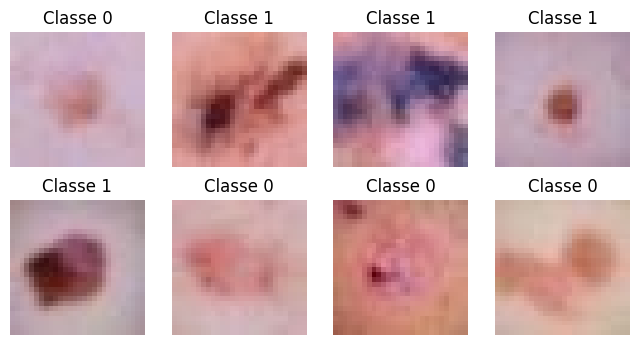

In [339]:
images_train[random.randint(0,199)]
images_train[random.randint(200,399)]

n_imgs = 4
fig, axs = plt.subplots(2,n_imgs,figsize=(8, 4))

for n in range(n_imgs):
  plt.subplot(2,n_imgs,n+1)
  plt.axis('off')
  tmp = random.randint(0,199)
  plt.imshow(images_train[tmp])
  plt.title(f'Classe {labels_train[tmp]}')

  plt.subplot(2,n_imgs,n+n_imgs+1)
  plt.axis('off')
  tmp = random.randint(200,399)
  plt.imshow(images_train[tmp])
  plt.title(f'Classe {labels_train[tmp]}')

**a)** Crie uma função que receba um conjunto de imagens RGB, transforme as imagens em *grayscale*, e extraia os atributos do histograma de cada imagem. A função deve retornar os atributos dos histogramas concatenados em um vetor de atributos. Utilize a função **"histstat"** dada nesse notebook para extração de atributos.

Utilize os conjuntos de dados criados anteriormente para obter os vetores de atributos das amostras de treino e teste (train_features e test_features).

**Atenção!** Para o conjunto de treino você deve obter uma matriz 400 x 9, onde cada linha corresponde a uma amostra (imagem) e cada coluna correponde a um atributo do histograma. Da mesma forma, para o conjunto de teste você deve obter uma matriz 100 x 9.

In [340]:
# Seu código aqui
def extrair_features(images):
  features = []

  for img in images:
    gray = np.uint8(0.3*img[:,:,0]+0.59*img[:,:,1]+0.11*img[:,:,2])
    stats = histstat(gray)
    features.append(stats)

  return np.array(features)

train_features = extrair_features(images_train)
test_features = extrair_features(images_test)

**b)** Treine um modelo kNN utilizando o conjunto de dados de treino criado (train_features). Você precisará escolher um valor de k. Valide o modelo utilizando o conjunto de dados de teste (test_features). Calcule as métricas de avaliação do classificador para ambos os conjuntos de dados (primeiro para treino, depois para teste): acurácia, precisão, revocação e F1-score. Imprima a [Matriz de Confusão](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html).


In [341]:
# Seu código aqui
k = 5

knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(train_features, labels_train)

test_pred = knn.predict(test_features)

print("Acurácia:", accuracy_score(labels_test, test_pred))
print("Precisão:", precision_score(labels_test, test_pred))
print("Revocação:", recall_score(labels_test, test_pred))
print("F1-score:", f1_score(labels_test, test_pred))
print("Matriz de confusão:\n", confusion_matrix(labels_test, test_pred))


Acurácia: 0.81
Precisão: 0.7719298245614035
Revocação: 0.88
F1-score: 0.822429906542056
Matriz de confusão:
 [[37 13]
 [ 6 44]]


**c)** Tente plotar os resultados da classificação usando os atributos 2 a 2 como eixos (por exemplo, os valores de variância no eixo y e os valores de média no eixo x). Utilize a função [scatter()](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html) do matplotlib, já demonstrada no início da Parte 3 deste notebook. As amostras de treinamento devem ser plotadas com pontos circulares, enquanto as amostras de teste devem ser plotadas com pontos cruzados. Comente os resultados obtidos.

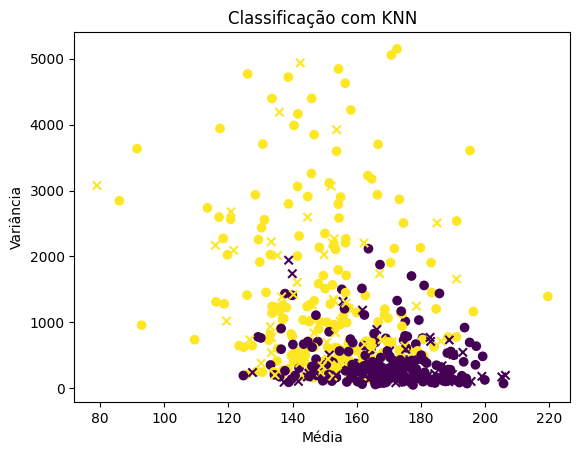

Uma das classes (amarela) está bem mais dispersa (principalmente com relação à variância)
 enquanto outra apresenta uma alta concentração em baixa variância. Tembém é possível perceber que
 existe certa sobreposição entre as classes, que dificulta a classificação.
 Apesar disso, os resultados do teste (principalmente roxo) se aproximou bem do treino.


In [342]:
# Seu código aqui
plt.scatter(train_features[:, 0], train_features[:, 1], c=labels_train)
plt.scatter(test_features[:, 0], test_features[:, 1], marker='x', c=labels_test)
plt.xlabel("Média")
plt.ylabel("Variância")
plt.title('Classificação com KNN')
plt.show()
print("Uma das classes (amarela) está bem mais dispersa (principalmente com relação à variância)\n",
      "enquanto outra apresenta uma alta concentração em baixa variância. Tembém é possível perceber que\n",
      "existe certa sobreposição entre as classes, que dificulta a classificação.\n",
      "Apesar disso, os resultados do teste (principalmente roxo) se aproximou bem do treino.")

**d)** Comente os resultados obtidos: Você está satisfeito com o resultado? O que você pode inferir do seu classificador ao observar as métricas obtidas? Qual o erro mais frequente? Quais modificações poderiam ser feitas para tentar obter melhores resultados?

Resposta: Os resultados obtidos são razoáveis, apresentando acurácia em torno de 80%. Isso indica que o modelo consegue diferenciar parcialmente as classes apesar de haver certa sobreposição entre os dados, o que sugere que algumas amostras possuem características semelhantes e limita o desempenho do modelo. as mudanças dos próximos exercícios (alterar o valor de k, usar imagens coloridas e atributos de textura por exemplo) podem ajudar a melhorar o modelo.

### Exercício 3.2

Tente melhorar os resultados de classificação. Algumas sugestões:

- Redimensione as imagens para um tamanho menor **(14, 14)**, isso pode deixar os atributos menos suceptíveis a ruídos e detalhes, focando a classificação em características mais gerais;
- Altere o valor de vizinhos k;
- Em problemas de classificação, especialmente quando temos poucas amostras e muitos atributos, temos o "mal da dimensionalidade". A seleção de atributos pode ser utilizada para contornar esse problema e remover atributos reduntantes (correlacionados) ou irrelevantes. Você pode escolher atributos aleatoriamente, fazer uma análise estatística dos atributos correlacionados, ou ainda fazer uma análise visual. Pode também usar técnicas específicas de seleção de atributos ([feature selection](https://scikit-learn.org/stable/modules/feature_selection.html#feature-selection)).

Acurácia: 0.86
Precisão: 0.8214285714285714
Revocação: 0.92
F1-score: 0.8679245283018868
Matriz de confusão:
 [[40 10]
 [ 4 46]]


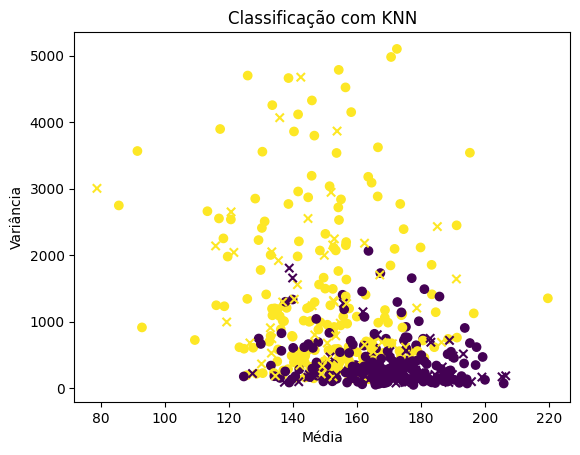

As mudanças em k e o redimensionamento das imagens melhorou o modelo, mas ainda não
 lidou com o maior problema: a sobreposição das duas classes. Experimentei alterar as features
 utilizadas baseado em uma análise visual, mas todas resultaram em situações com sobreposição semalhante.


In [343]:
# Seu código aqui
def resize_images(images, size=(14,14)):
    resized = []

    for img in images:
        img_pil = Image.fromarray(img)
        img_resized = img_pil.resize(size)
        resized.append(np.array(img_resized))

    return resized


resized_train = resize_images(images_train)
resized_test = resize_images(images_test)

resized_train_features = extrair_features(resized_train)
resized_test_features = extrair_features(resized_test)

k = 7

model = KNeighborsClassifier(n_neighbors=k)
model.fit(resized_train_features, labels_train)

test_pred = model.predict(resized_test_features)

print("Acurácia:", accuracy_score(labels_test, test_pred))
print("Precisão:", precision_score(labels_test, test_pred))
print("Revocação:", recall_score(labels_test, test_pred))
print("F1-score:", f1_score(labels_test, test_pred))
print("Matriz de confusão:\n", confusion_matrix(labels_test, test_pred))

plt.scatter(resized_train_features[:, 0], resized_train_features[:, 1], c=labels_train)
plt.scatter(resized_test_features[:, 0], resized_test_features[:, 1], marker='x', c=labels_test)
plt.xlabel("Média")
plt.ylabel("Variância")
plt.title('Classificação com KNN')
plt.show()

print("As mudanças em k e o redimensionamento das imagens melhorou o modelo, mas ainda não\n",
      "lidou com o maior problema: a sobreposição das duas classes. Experimentei alterar as features\n",
      "utilizadas baseado em uma análise visual, mas todas resultaram em situações com sobreposição semalhante.")


## Parte 4 - Utilizando atributos de histograma de imagens coloridas (opicional para EA979)

Note que, ao realizar a transformação das imagens coloridas para imagens em escala de cinza na Parte 3 deste notebook, estamos desconsiderando características e informações das imagens com potencial para ajudar no processo de classificação.

### Exercício 4.1

Repita o processo de classificação do dataset de imagens dermatoscópicas, mas desta vez utilizando atributos de histograma extraídos diretamente das imagens coloridas (sem transformá-las para escala de cinza). Explique como a extração de atributos foi realizada e comente sobre os resultados obtidos. Lembre-se de tentar aplicar também as modificações utilizadas no exercício 3.2 para melhorar os resultados de classificação. Alguma das bandas da imagem se mostrou mais eficaz para a classificação? Os resultados de classificação foram melhores ou piores em relação a utilizar as imagens em escala de cinza? Comente.

Acurácia: 0.85
Precisão: 0.8301886792452831
Revocação: 0.88
F1-score: 0.8543689320388349
Matriz de confusão:
 [[41  9]
 [ 6 44]]


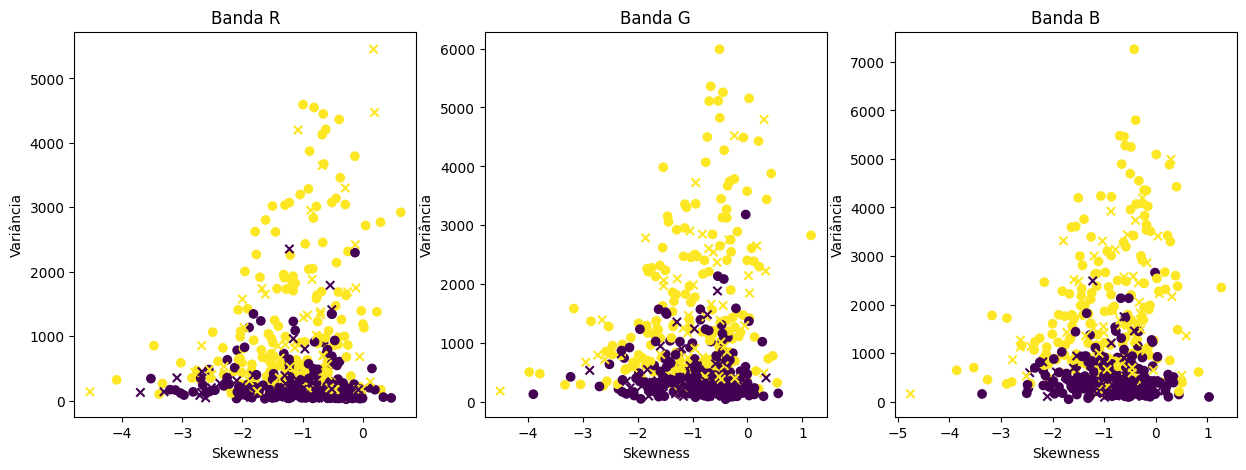

A banda azul se mostrou mais eficaz entre as três, apesar de serem bem similares. O treino com imagens 
 coloridas melhorou um pouco o modelo quando comparado às imagens cinzas, mas ainda exibe muita sobreposição,
 mostrando que deve haver outros atributos que impactem mais esse tipo de classificação (textura como o próximo 
 exercício sugere).


In [344]:
# Seu código aqui# Seu código aqui
def extrair_features_rgb(images):
  features = []

  for img in images:
    r = img[:,:,0]
    g = img[:,:,1]
    b = img[:,:,2]

    r_stats = histstat(r)
    g_stats = histstat(g)
    b_stats = histstat(b)

    feat = np.concatenate((r_stats,g_stats,b_stats))

    features.append(feat)

  return np.array(features)

rgb_train = resize_images(images_train)
rgb_test = resize_images(images_test)

rgb_train_features = extrair_features_rgb(rgb_train)
rgb_test_features = extrair_features_rgb(rgb_test)

k = 7

model_rgb = KNeighborsClassifier(n_neighbors=k)
model_rgb.fit(rgb_train_features, labels_train)

test_pred_rgb = model_rgb.predict(rgb_test_features)

print("Acurácia:", accuracy_score(labels_test, test_pred_rgb))
print("Precisão:", precision_score(labels_test, test_pred_rgb))
print("Revocação:", recall_score(labels_test, test_pred_rgb))
print("F1-score:", f1_score(labels_test, test_pred_rgb))
print("Matriz de confusão:\n", confusion_matrix(labels_test, test_pred_rgb))

fig, axs = plt.subplots(1, 3, figsize=(15,5))

feature1 = 2
feature2 = 1

axs[0].scatter(rgb_train_features[:, feature1], rgb_train_features[:, feature2], c=labels_train)
axs[0].scatter(rgb_test_features[:, feature1], rgb_test_features[:, feature2], marker='x', c=labels_test)
axs[0].set_title("Banda R")
axs[0].set_xlabel("Skewness")
axs[0].set_ylabel("Variância")

axs[1].scatter(rgb_train_features[:, 9+feature1], rgb_train_features[:, 9+feature2], c=labels_train)
axs[1].scatter(rgb_test_features[:, 9+feature1], rgb_test_features[:, 9+feature2], marker='x', c=labels_test)
axs[1].set_title("Banda G")
axs[1].set_xlabel("Skewness")
axs[1].set_ylabel("Variância")

axs[2].scatter(rgb_train_features[:, 18+feature1], rgb_train_features[:, 18+feature2], c=labels_train)
axs[2].scatter(rgb_test_features[:, 18+feature1], rgb_test_features[:, 18+feature2], marker='x', c=labels_test)
axs[2].set_title("Banda B")
axs[2].set_xlabel("Skewness")
axs[2].set_ylabel("Variância")

plt.show()

print("A banda azul se mostrou mais eficaz entre as três, apesar de serem bem similares. O treino com imagens \n",
      "coloridas melhorou um pouco o modelo quando comparado às imagens cinzas, mas ainda exibe muita sobreposição,\n",
      "mostrando que deve haver outros atributos que impactem mais esse tipo de classificação (textura como o próximo \n",
      "exercício sugere).")


## Parte 5 - Explorando atributos de textura (opicional para EA979)

Além dos atributos de histograma, existem diversos outros tipos de atributos que podem ser extraídos de imagens digitais, como os atributos de textura, por exemplo. No processamento de imagens, a textura pode ser definida em função da variação espacial da intensidade dos pixels em uma região da imagem. Os atributos de textura são úteis para caracterizar padrões em uma imagem, como rugosidade, suavidade, granulosidade, entre outros. Assim, a análise de textura desempenha um papel importante em casos de visão computacional, como reconhecimento de objetos, detecção de defeitos de superfície, reconhecimento de padrões, análise de imagens médicas, etc.

**Para saber mais sobre atributos de textura, verifique os materiais de apoio disponibilizados no classroom.**

### Exercício 5.1

Extraia atributos de textura (como [GLCM](https://scikit-image.org/docs/stable/auto_examples/features_detection/plot_glcm.html), por exemplo) e repita a classificação. Comente sobre o método de extração de atributos escolhido (como funciona? quais seus parâmetros? que atributos consegue extrair?) e os resultados obtidos.

In [345]:
from skimage.feature import graycomatrix, graycoprops
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

scaler = StandardScaler()

def extrair_glcm_features(images):
    features = []

    for img in images:
        gray = np.uint8(0.3*img[:,:,0]+0.59*img[:,:,1]+0.11*img[:,:,2])
        gray = (gray / 16).astype(np.uint8)

        glcm = graycomatrix(
            gray,
            distances=[1, 2],
            angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
            levels=16,
            symmetric=True,
            normed=True
        )

        contrast = graycoprops(glcm, 'contrast').flatten()
        correlation = graycoprops(glcm, 'correlation').flatten()
        energy = graycoprops(glcm, 'energy').flatten()
        homogeneity = graycoprops(glcm, 'homogeneity').flatten()

        feat = np.concatenate((contrast, correlation, energy, homogeneity))
        features.append(feat)

    return np.array(features)

Acurácia: 0.87
Precisão: 0.8490566037735849
Revocação: 0.9
F1-score: 0.8737864077669902
Matriz de confusão:
 [[42  8]
 [ 5 45]]


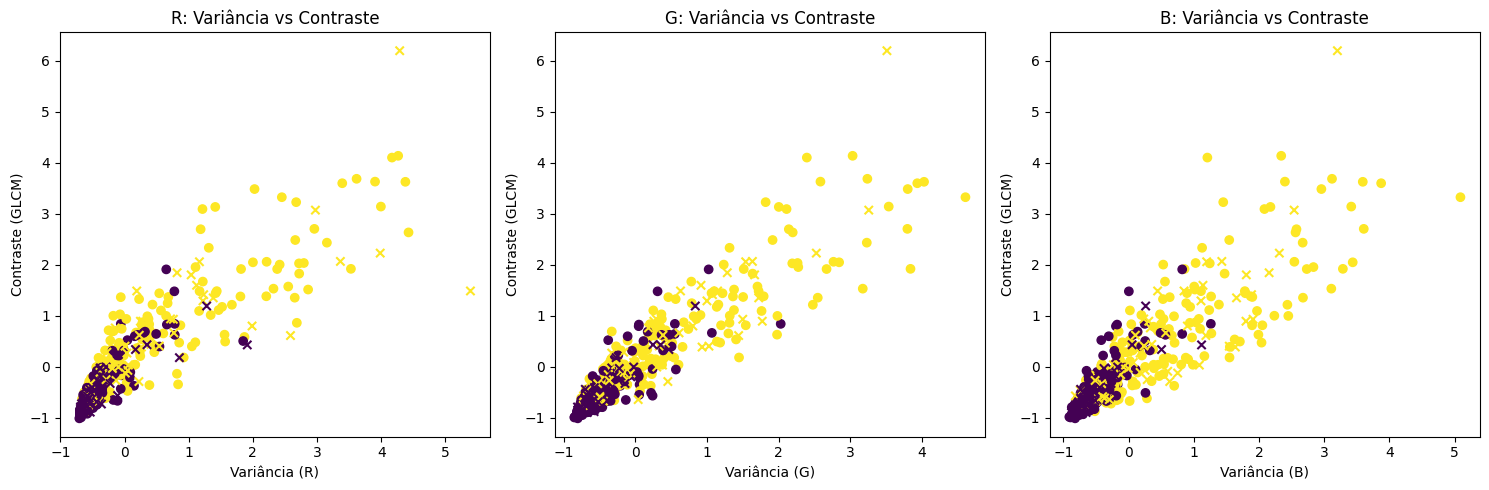

O método GCLM (Gray-Level Co-occurrence Matrix) transforma padrões de pixels em formas de 
 descrever textura através de números. ele analisa como pares de níveis de cinza ocorrem juntos
 para extrair características como contraste, homogeneidade, energia (repetição de padrões) e correlação.
 
Os resultados obtidos foram os melhores da atividade, apresentando 87% de acurácia e a menos quantidade
 de falsos negativos. apesar disso, o modelo ainda pode melhorar, dado que ainda há muita sobreposição.


In [346]:
# Seu código aqui
rgb_train_features = extrair_features_rgb(rgb_train)
rgb_test_features = extrair_features_rgb(rgb_test)

glcm_train_features = extrair_glcm_features(rgb_train)
glcm_test_features = extrair_glcm_features(rgb_test)

train_features = np.concatenate((rgb_train_features, glcm_train_features), axis=1)
test_features = np.concatenate((rgb_test_features, glcm_test_features), axis=1)

train_features = scaler.fit_transform(train_features)
test_features = scaler.transform(test_features)

k = 7
selector = SelectKBest(f_classif, k=20)

train_sel = selector.fit_transform(train_features, labels_train)
test_sel = selector.transform(test_features)

model.fit(train_sel, labels_train)
pred_glcm = model.predict(test_sel)

print("Acurácia:", accuracy_score(labels_test, pred_glcm))
print("Precisão:", precision_score(labels_test, pred_glcm))
print("Revocação:", recall_score(labels_test, pred_glcm))
print("F1-score:", f1_score(labels_test, pred_glcm))
print("Matriz de confusão:\n", confusion_matrix(labels_test, pred_glcm))


fig, axs = plt.subplots(1, 3, figsize=(15,5))

contrast_idx = 28

axs[0].scatter(train_features[:, 1], train_features[:, contrast_idx], c=labels_train)
axs[0].scatter(test_features[:, 1], test_features[:, contrast_idx], marker='x', c=labels_test)
axs[0].set_title("R: Variância vs Contraste")
axs[0].set_xlabel("Variância (R)")
axs[0].set_ylabel("Contraste (GLCM)")

axs[1].scatter(train_features[:, 10], train_features[:, contrast_idx], c=labels_train)
axs[1].scatter(test_features[:, 10], test_features[:, contrast_idx], marker='x', c=labels_test)
axs[1].set_title("G: Variância vs Contraste")
axs[1].set_xlabel("Variância (G)")
axs[1].set_ylabel("Contraste (GLCM)")

axs[2].scatter(train_features[:, 19], train_features[:, contrast_idx], c=labels_train)
axs[2].scatter(test_features[:, 19], test_features[:, contrast_idx], marker='x', c=labels_test)
axs[2].set_title("B: Variância vs Contraste")
axs[2].set_xlabel("Variância (B)")
axs[2].set_ylabel("Contraste (GLCM)")

plt.tight_layout()
plt.show()

print("O método GCLM (Gray-Level Co-occurrence Matrix) transforma padrões de pixels em formas de \n",
      "descrever textura através de números. ele analisa como pares de níveis de cinza ocorrem juntos\n",
      "para extrair características como contraste, homogeneidade, energia (repetição de padrões) e correlação.\n",
      "\nOs resultados obtidos foram os melhores da atividade, apresentando 87% de acurácia e a menos quantidade\n",
      "de falsos negativos. apesar disso, o modelo ainda pode melhorar, dado que ainda há muita sobreposição.")
